# Cálculo da susceptibilidade, probabilidade e perigosidade

Integração das as variáveis preparadas anteriormente para calcular a susceptibilidade, a probabilidade e a perigosidade de incêndio na área de estudo.

In [8]:
from glass.ete.lri import HeuristicLri
import os

#teste

import sys

sys.path.append("/code/scripts")

from lri_sum import HeuristicLriCount

In [2]:
#dem = '/code/data/processed/pnse/topo/reclassified/rcls_dem_pnse.tif'
dem = '/code/data/processed/centro/topo/reclassified/rcls_dem_centro.tif'

ws = '/code/data/results/centro/lr/final'

bareas = '/code/data/processed/centro/area_ardida/raster_count/rst_ba_1995_2024.tif' #n tá pronto
bareas_by_year = '/code/data/processed/centro/area_ardida/train'

_vars = {
    'dem'    : '/code/data/processed/centro/topo/reclassified/rcls_dem_centro.tif',
    'slope'  : '/code/data/processed/centro/topo/reclassified/rcls_slope_centro.tif',
    #'aspect' : '/code/data/processed/centro/topo/reclassified/rcls_aspect_centro.tif'
}

lulcs = [
    '/code/data/processed/centro/lulc/rasters/lulc_1995.tif',
    '/code/data/processed/centro/lulc/rasters/lulc_2007.tif',
    '/code/data/processed/centro/lulc/rasters/lulc_2010.tif',
    '/code/data/processed/centro/lulc/rasters/lulc_2015.tif',
    '/code/data/processed/centro/lulc/rasters/lulc_2018.tif',
]

burncos = [
    '/code/data/processed/centro/area_ardida/raster_count/rst_ba_1995_2006.tif',
    '/code/data/processed/centro/area_ardida/raster_count/rst_ba_2007_2009.tif',
    '/code/data/processed/centro/area_ardida/raster_count/rst_ba_2010_2014.tif',
    '/code/data/processed/centro/area_ardida/raster_count/rst_ba_2015_2017.tif',
    '/code/data/processed/centro/area_ardida/raster_count/rst_ba_2018_2024.tif',
]

weights = [12, 3, 5, 3, 7] #pesos associaados à estratégia temporal LULC-Areas Ardidas

out_dir = '/code/data/results/centro/lr/final'
os.makedirs(out_dir, exist_ok=True)

out_susc = f"{out_dir}/res_lri.tif"
out_prob = f"{out_dir}/wprobability.tif"
out_peri = f"{out_dir}/res_perigosity.tif"

In [9]:
#lri = HeuristicLri(ws, dem, loc=None)
lri = HeuristicLriCount(ws, dem, loc=None)

In [10]:
# Import topographic variables

#lri.import_topo_vars(dem=_vars['dem'], slope=_vars['slope'], aspect=_vars['aspect'])
lri.import_topo_vars(dem=_vars['dem'], slope=_vars['slope'])

# Import events
lri.import_events(bareas)

         overwritten


In [11]:
# Import LULC variables
lri.import_lulc_vars(lulcs, weights, burncos)

In [12]:
# Generate LRI
lri_res = lri.calc_lri(out=out_susc)

/usr/lib/python3/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [13]:
lri.export_vars_lri(os.path.dirname(out_susc), 'lri')

In [14]:
# Generate Wildfire probability

#wprob = lri.wildfire_probability(bareas_by_year, out=out_prob)

""" 
erro ao correr a linha acima comentada

CalledModuleError: Module run `r.mapcalc expression=/code/data/results_lri_pnse/wprobability.tif = (rst_aa_2000 + 
rst_aa_2014 + rst_aa_2015 + rst_aa_2001 + rst_aa_2017 + rst_aa_2003 + rst_aa_2002 + rst_aa_2016 + rst_aa_2012 + rst_aa_2006 + 
rst_aa_2007 + rst_aa_2013 + rst_aa_2005 + rst_aa_2011 + rst_aa_2010 + rst_aa_2004 + rst_aa_1998 + rst_aa_1999 + rst_aa_1975 + 
rst_aa_1989 + rst_aa_1976 + rst_aa_1977 + rst_aa_1988 + rst_aa_1991 + rst_aa_1985 + rst_aa_1984 + rst_aa_1990 + rst_aa_1986 + 
rst_aa_1992 + rst_aa_1979 + rst_aa_1978 + rst_aa_1993 + rst_aa_1987 + rst_aa_1983 + rst_aa_1997 + rst_aa_1996 + rst_aa_1982 + 
rst_aa_1994 + rst_aa_1980 + rst_aa_1981 + rst_aa_1995 + rst_aa_2009 + rst_aa_2021 + rst_aa_2020 + rst_aa_2008 + rst_aa_2022 + 
rst_aa_2023 + rst_aa_2018 + rst_aa_2019) / 49.0 region=current --o --q` ended with an error.
The subprocess ended with a non-zero return code: 1. See errors above the traceback or in the error output.
"""

# Generate Wildfire probability - solução encontrada 
from glob import glob
from glass.rst.stats.grs import count_regionshp
from glass.it.rst import grs_to_rst

train_shps = sorted(glob(f"{bareas_by_year}/aa_*.shp"))

lri.wildfireprob = count_regionshp(
    train_shps,
    'rst_wildfireprob',
    return_prob=True,
    nnprob=len(train_shps),
)

grs_to_rst(lri.wildfireprob, out_prob, dtype="Float64", nodata=-1)

         Unable to calculate a centroid for 1 areas


'/code/data/results/centro/lr/final/wprobability.tif'

In [15]:
""" 
comentado devido ao erro da célula anterior 
"""


#from glass.it.rst import grs_to_rst

#wprob = lri.wildfire_probability(bareas_by_year)
#grs_to_rst(wprob, out_prob, dtype="Float64", nodata=-1)

' \ncomentado devido ao erro da célula anterior \n'

In [16]:
# Generate perigosity

#lri.get_perigosity(out=out_peri)    

""" 
erro ao correr a linha acima comentada - mesmo erro ao calcular probabilidade
"""

# Generate perigosity - solução encontrada
lri.get_perigosity(
    inlri=out_susc,
    wildprob=out_prob,
    out=out_peri
)

'/code/data/results/centro/lr/final/res_perigosity.tif'

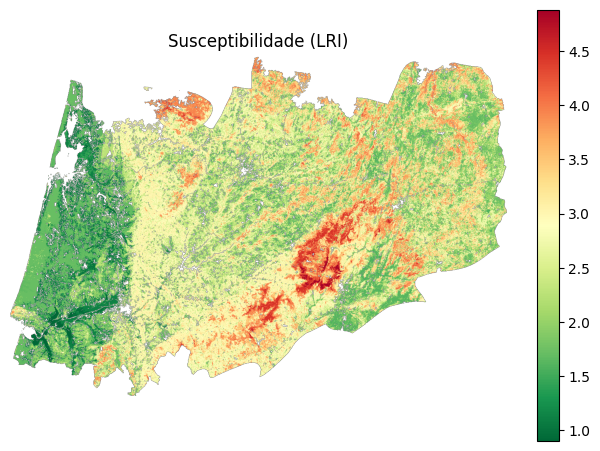

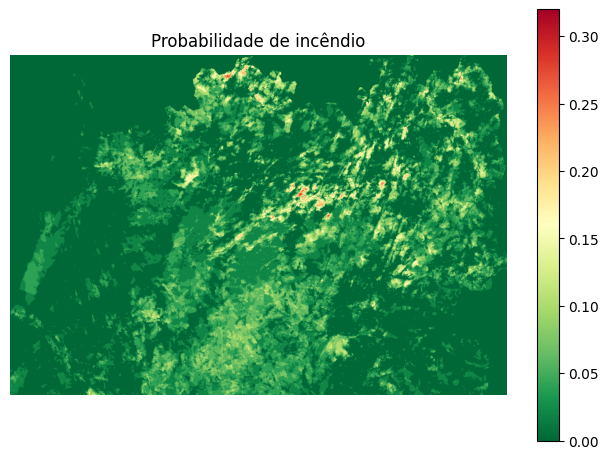

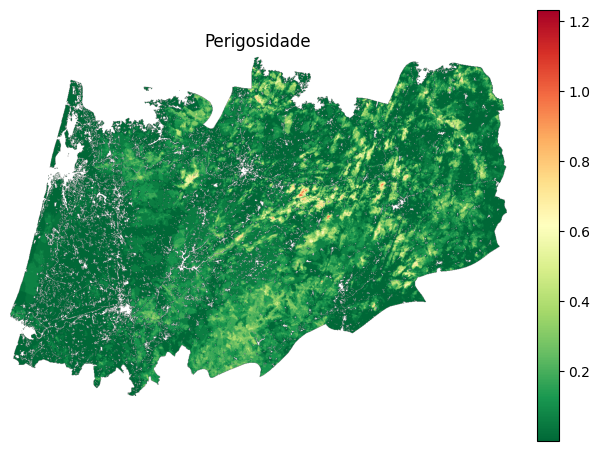

In [17]:
import math
import rasterio as rio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import numpy as np

def quick_raster_plot(path, title=None, max_dim=1200, categorical=False, cmap='RdYlGn_r'):
    with rio.open(path) as src:
        h, w = src.height, src.width
        scale = max(1, math.ceil(max(h, w) / max_dim))

        data = src.read(
            1,
            out_shape=(1, max(1, h // scale), max(1, w // scale)),
            resampling=Resampling.nearest
        )

        nodata = src.nodata
        if nodata is not None:
            data = np.ma.masked_equal(data, nodata)

    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap=cmap)
    plt.title(title or path)
    plt.colorbar(shrink=0.7)
    plt.axis("off")
    plt.show()

quick_raster_plot(out_susc, "Susceptibilidade (LRI)")
quick_raster_plot(out_prob, "Probabilidade de incêndio")
quick_raster_plot(out_peri, "Perigosidade")